In [1]:
import pandas as pd
import numpy as np

In [2]:
# ! pip install graphviz

In [3]:
# Load example data
df = pd.read_csv("diabetes.csv")

# Example columns: Age, Gender, BloodPressure, Treatment, Outcome
df = df.dropna()  # Or impute missing data

In [4]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

# Causal Estimate: Quantifies how much Glucose causes changes in Outcome (diabetes).

In [6]:
# Goal: Estimate causal effect of Glucose on Outcome using:
#     backdoor.linear_regression
#     backdoor.propensity_score_matching
#     backdoor.random_forest
#     iv.instrumental_variable

In [7]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from dowhy import CausalModel
# from IPython.display import Image, display
# from econml.dml import DML
# from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
# from sklearn.linear_model import LassoCV


In [8]:
# # Step 1: Load dataset
# df = pd.read_csv("diabetes.csv")

# # Step 2: Preprocess: Replace zeros in clinical columns with NaN
# for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
#     df[col] = df[col].replace(0, np.nan)
# df.dropna(inplace=True)

# # Step 3: Create binary treatment from Glucose
# df["high_glucose"] = (df["Glucose"] > 125).astype(int)
# treatment = "high_glucose"
# outcome = "Outcome"

# # Step 4: Manually define a causal graph based on domain knowledge
# causal_graph = """
# digraph {
#     Age -> high_glucose;
#     Age -> Outcome;
#     BMI -> high_glucose;
#     BMI -> Outcome;
#     Pregnancies -> high_glucose;
#     Pregnancies -> Outcome;
#     high_glucose -> Outcome;
# }
# """

# # Step 5: Create the causal model
# model = CausalModel(
#     data=df,
#     treatment=treatment,
#     outcome=outcome,
#     graph=causal_graph
# )
# # model.view_model()

# # Save and display causal graph
# display(Image(filename="causal_model.png"))

# # Step 6: Identify the causal effect
# identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
# print("Identified estimand:\n", identified_estimand)

# # Step 7: Estimate with different methods
# print("\n=== Estimation: Linear Regression ===")
# estimate_lr = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression")
# print("Estimate:", estimate_lr.value)

# print("\n=== Estimation: Propensity Score Matching ===")
# estimate_psm = model.estimate_effect(identified_estimand, method_name="backdoor.propensity_score_matching")
# print("Estimate:", estimate_psm.value)

# print("\n=== Estimation: EconML DML with Random Forest ===")

# # Define DML estimator
# dml_estimator = DML(
#     model_y=RandomForestRegressor(n_estimators=100),
#     model_t=RandomForestClassifier(n_estimators=100),
#     model_final=LassoCV(),
#     discrete_treatment=True
# )

# dml_estimator.fit(
#     Y=df[outcome].values,
#     T=df[treatment].values,
#     X=df[["Age", "BMI", "Pregnancies"]].values
# )

# ate_dml = dml_estimator.ate(X=df[["Age", "BMI", "Pregnancies"]].values)
# print("Estimate:", ate_dml)

# print("\n=== Estimation: Instrumental Variable ===")
# # Choose an instrument that affects treatment but not directly outcome (e.g., 'Pregnancies')
# estimate_iv = model.estimate_effect(
#     identified_estimand,
#     method_name="iv.instrumental_variable",
#     method_params={"iv_instrument_name": "Pregnancies"}
# )
# print("Estimate:", estimate_iv.value)

# # # Step 8: Refute estimates (for one or more)
# # print("\n=== Refutation: Linear Regression ===")
# # refute_lr = model.refute_estimate(
# #     identified_estimand,
# #     estimate_lr,
# #     method_name="placebo_treatment_refuter",
# #     method_params={"placebo_type": "permute"}
# # )
# # print(refute_lr)

# # refute_lr2 = model.refute_estimate(
# #     identified_estimand,
# #     estimate_lr,
# #     method_name="random_common_cause"
# # )
# # print(refute_lr2)

# # # Step 9: Refute IV estimate using only supported placebo type
# # print("\n=== Refutation: Instrumental Variable ===")
# # refute_iv = model.refute_estimate(
# #     identified_estimand,
# #     estimate_iv,
# #     method_name="placebo_treatment_refuter",
# #     method_params={"placebo_type": "permute"}
# # )
# # print(refute_iv)


# Other Program

In [9]:
# code loads a diabetes dataset, preprocesses it, defines a causal model with a specified causal graph (DAG), 
# identifies and estimates the causal effect of Glucose on Outcome (diabetes diagnosis), and finally performs 
# robustness checks (refutations) on the estimated causal effect.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dowhy import CausalModel
from sklearn.model_selection import train_test_split
import warnings

/rodata/kern/m254629/miniconda3/envs/llama2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


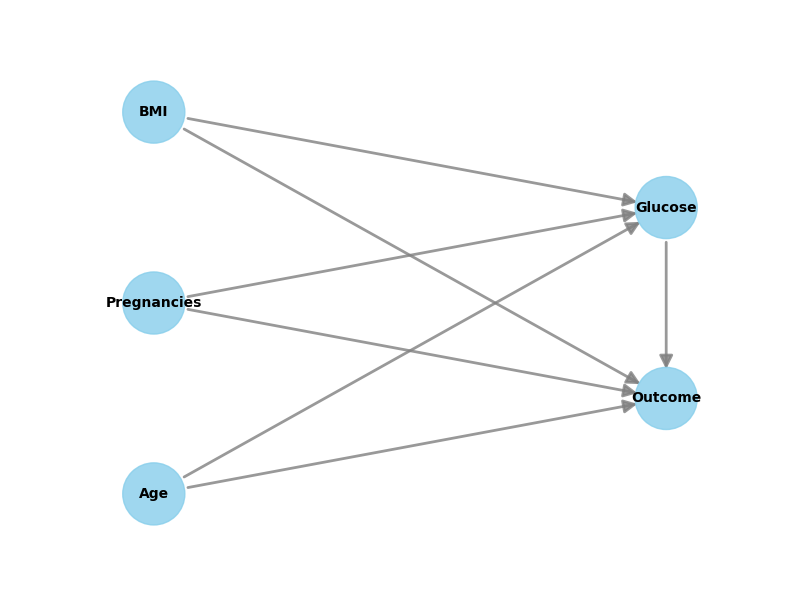

Identified estimand: Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                     
──────────(E[Outcome|BMI,Pregnancies,Age])
d[Glucose]                                
Estimand assumption 1, Unconfoundedness: If U→{Glucose} and U→Outcome then P(Outcome|Glucose,BMI,Pregnancies,Age,U) = P(Outcome|Glucose,BMI,Pregnancies,Age)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                     
──────────(E[Outcome|BMI,Pregnancies,Age])
d[Glucose]                                
Estimand assumption 1, Unconfoundedness: If U→{Glucose} and U→Outcome then P(Outcome|Glucose,BMI,Pregnancies,Age,U) = P(Outcome|Glucose,BMI,Pregnancies,Age)

### Estimand : 2
Estimand name: iv
No such variable(s)

In [11]:
# Suppress FutureWarning for Series.__getitem__
warnings.filterwarnings("ignore", category=FutureWarning, message="Series.__getitem__ treating keys as positions is deprecated.*")

# Step 1: Load the dataset
df = pd.read_csv("diabetes.csv")

# Step 2: Preprocess data (optional: remove zeroes in critical columns)
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df[col] = df[col].replace(0, np.nan)
df.dropna(inplace=True)

# Step 3: Define treatment, outcome, and causal graph
treatment = "Glucose"
outcome = "Outcome"

# Step 4: Define causal DAG as string (manually assumed based on clinical intuition)
causal_graph = """
digraph {
    Age -> Glucose;
    Age -> Outcome;
    BMI -> Glucose;
    BMI -> Outcome;
    Pregnancies -> Glucose;
    Pregnancies -> Outcome;
    Glucose -> Outcome;
}
"""

# Step 5: Create the CausalModel
model = CausalModel(
    data=df,
    treatment=treatment,
    outcome=outcome,
    graph=causal_graph
)
# model.view_model()

# (Optional) Save graph to file
from IPython.display import Image, display
display(Image(filename="causal_model.png"))

# Step 6: Identify the causal effect
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print("Identified estimand:", identified_estimand)
print(identified_estimand)
print()

# Step 7: Estimate the causal effect using a backdoor method
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)

# Use iloc if estimate.value is a Series
causal_value = estimate.value.iloc[0] if hasattr(estimate.value, 'iloc') else estimate.value
print("Causal Estimate:", causal_value)

# Step 8: Refute the estimate with robustness checks
refutation1 = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"  # Required for IV or to avoid error
)
print(refutation1)

refutation2 = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause"
)
print(refutation2)

# Use Neural Network on the data

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from dowhy import CausalModel
from dowhy.causal_estimator import CausalEstimator

# Step 1: Load and preprocess dataset
df = pd.read_csv("diabetes.csv")
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df[col] = df[col].replace(0, np.nan)
df.dropna(inplace=True)

# Variables
treatment = "Glucose"
outcome = "Outcome"
confounders = ['Age', 'BMI', 'Pregnancies']

# Features and outcome
X = df[confounders + [treatment]].values
Y = df[outcome].values

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Step 2: Define neural network for outcome prediction
class OutcomeNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()  # binary output
        )
    def forward(self, x):
        return self.net(x)

model = OutcomeNN(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Prepare DataLoader
train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

# Training loop
model.train()
epochs = 100
for epoch in range(epochs):
    epoch_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device).unsqueeze(1)  # Move inputs and labels to device
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {epoch_loss/len(train_dl):.4f}")

# Step 3: Define causal graph and causal model with DoWhy
causal_graph = """
digraph {
    Age -> Glucose;
    Age -> Outcome;
    BMI -> Glucose;
    BMI -> Outcome;
    Pregnancies -> Glucose;
    Pregnancies -> Outcome;
    Glucose -> Outcome;
}
"""

model_dowhy = CausalModel(
    data=df,
    treatment=treatment,
    outcome=outcome,
    graph=causal_graph
)

identified_estimand = model_dowhy.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

# Step 4: Custom neural net causal effect estimation function
def nn_causal_estimate(data, treatment, outcome, model_nn, scaler, confounders):
    data_copy = data.copy()
    features = confounders + [treatment]

    # Predict with actual treatment values
    X_treated = scaler.transform(data_copy[features].values)
    model_nn.eval()
    with torch.no_grad():
        input_tensor = torch.tensor(X_treated, dtype=torch.float32).to(device)  # move input to device
        treated_preds = model_nn(input_tensor).cpu().numpy()

    # Predict with treatment set to 0 (control)
    data_copy[treatment] = 0
    X_control = scaler.transform(data_copy[features].values)
    with torch.no_grad():
        input_tensor = torch.tensor(X_control, dtype=torch.float32).to(device)  # move input to device
        control_preds = model_nn(input_tensor).cpu().numpy()

    # Estimate ATE
    ate = np.mean(treated_preds - control_preds)
    return ate

ate_nn = nn_causal_estimate(df, treatment, outcome, model, scaler, confounders)
print(f"Estimated ATE by neural net: {ate_nn}")

print("------------------")
print ("Step-5")
# Step 5: Wrap into a custom DoWhy estimator for refutation
class CustomNNEstimator(CausalEstimator):
    def _estimate_effect(self):
        ate = nn_causal_estimate(
            data=self._data,
            treatment=self._treatment_name,
            outcome=self._outcome_name,
            model_nn=model,
            scaler=scaler,
            confounders=confounders
        )
        return ate

custom_estimator = CustomNNEstimator(
    data=df,
    treatment=treatment,
    outcome=outcome,
    identified_estimand=identified_estimand,
    params=None
)

estimate_custom = custom_estimator.estimate_effect()
print(f"Custom NN estimate: {estimate_custom}")

# Step 6: Refute estimate with DoWhy
refute = model_dowhy.refute_estimate(
    identified_estimand,
    estimate_custom,
    method_name="random_common_cause"
)
print(refute)


Epoch 0, Loss: 0.6660
Epoch 20, Loss: 0.4495
Epoch 40, Loss: 0.4131
Epoch 60, Loss: 0.4006
Epoch 80, Loss: 0.3889
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                     
──────────(E[Outcome|BMI,Pregnancies,Age])
d[Glucose]                                
Estimand assumption 1, Unconfoundedness: If U→{Glucose} and U→Outcome then P(Outcome|Glucose,BMI,Pregnancies,Age,U) = P(Outcome|Glucose,BMI,Pregnancies,Age)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

Estimated ATE by neural net: 0.31679418683052063
------------------
Step-5


AttributeError: 'CustomNNEstimator' object has no attribute 'estimate_effect'